## BIODENOISING: Animal vocalization denoising

Code: https://github.com/earthspecies/biodenoising/ 
Paper: https://arxiv.org/abs/2410.03427

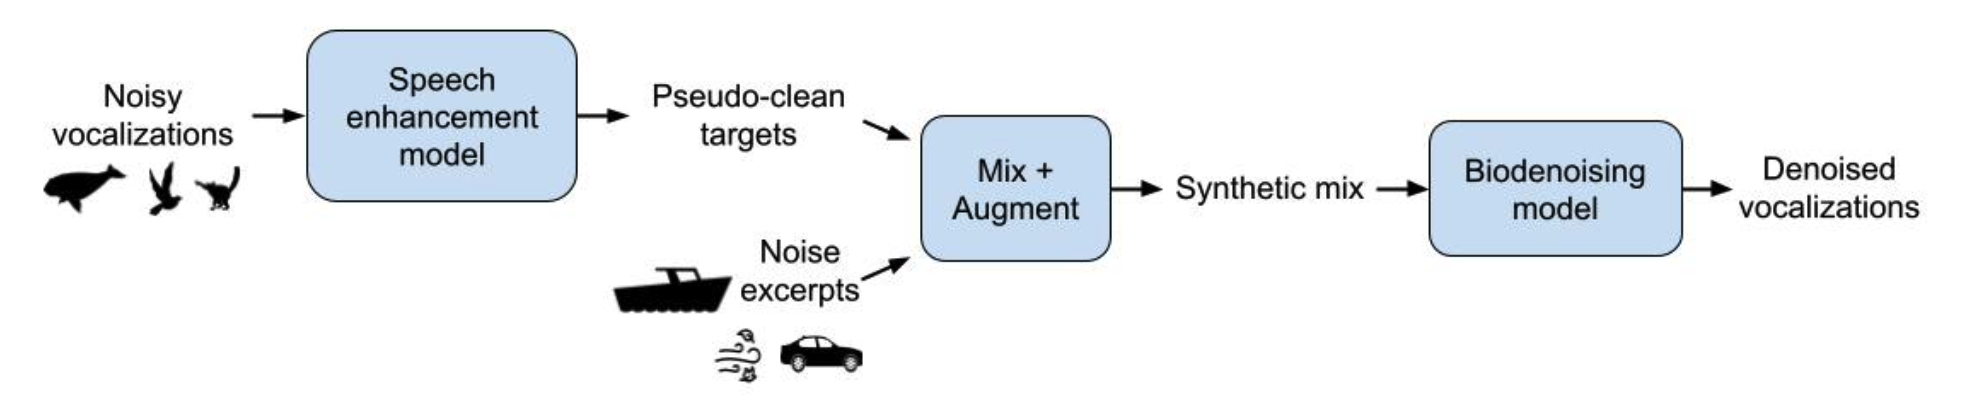


**Biodenoising**, a new method for animal vocalization denoising that does not require access to clean data. There are two core ideas behind Biodenoising:
* Leverage existing speech enhancement models: there is no need to start from scratch. Speech enhancement models have seen a lot of data and have some knowledge about patterns in audio time series.
* Following the same logic, there is no need to train a separate model for each animal dataset. Since lots of signal characteristics are replicated at different scales and frequencies, a model that has seen more diverse data can be more robust to unseen conditions and generalize better.
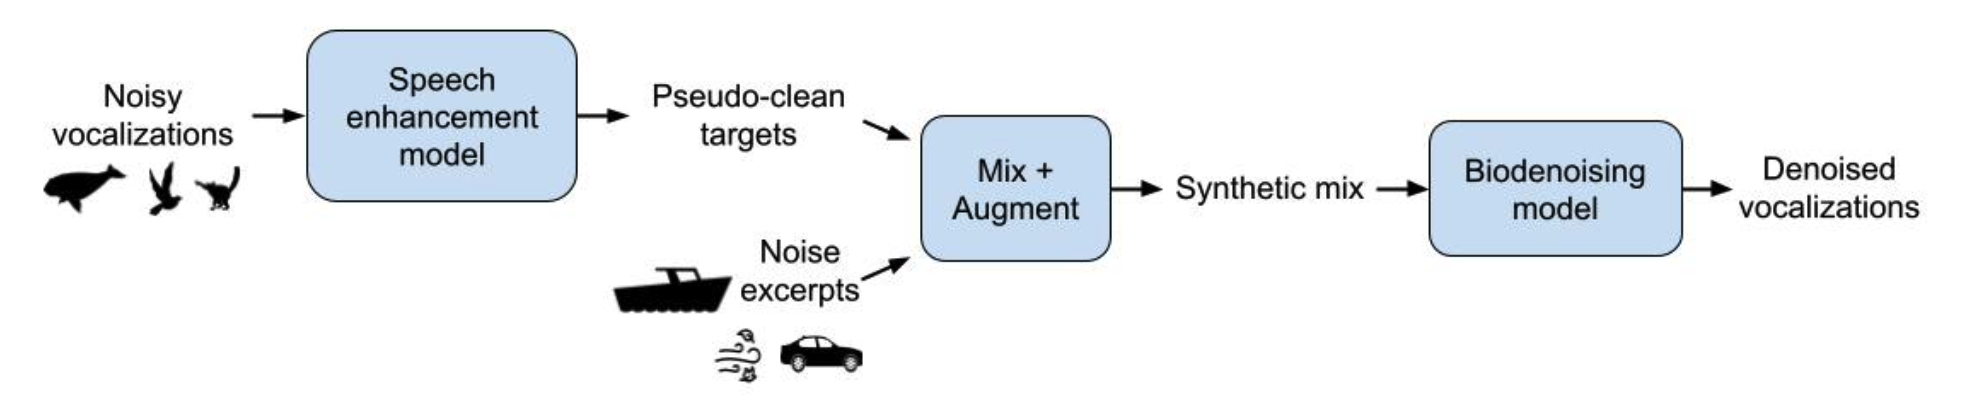

In [ ]:
%%capture
!pip install biodenoising

In [ ]:
from IPython import display as disp
import os
import torch
import torchaudio
import random
from biodenoising import pretrained
from biodenoising.denoiser.dsp import convert_audio
import matplotlib.pyplot as plt
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [ ]:
model = pretrained.biodenoising16k_dns48().to(device)

In [ ]:
wav, sr = torchaudio.load(os.path.join('/kaggle/input/birdclef-2025/train_audio/42007/iNat500217.ogg'))
wav = convert_audio(wav, sr, model.sample_rate, model.chin).to(device)
with torch.no_grad():
    denoised = model(wav[None])[0]
disp.display(disp.Audio(wav.data.cpu().numpy(), rate=model.sample_rate))
disp.display(disp.Audio(denoised.data.cpu().numpy(), rate=model.sample_rate))

## Random 10 audio from train

In [ ]:
base_dir = '/kaggle/input/birdclef-2025/train_audio'

ogg_files = []
for root, _, files in os.walk(base_dir):
    for file in files:
        if file.endswith('.ogg'):
            ogg_files.append(os.path.join(root, file))

selected_files = random.sample(ogg_files, 10)

In [ ]:
selected_files

In [ ]:
mel_spec = MelSpectrogram(
    sample_rate=model.sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=128
).to(device)
db_transform = AmplitudeToDB().to(device)

for f in selected_files:
    wav, sr = torchaudio.load(f)
    wav = convert_audio(wav, sr, model.sample_rate, model.chin).to(device)

    with torch.no_grad():
        denoised = model(wav[None])[0]

    def show_melspectrogram(audio_tensor, title):
        spec = mel_spec(audio_tensor)
        spec_db = db_transform(spec)
        plt.figure(figsize=(10, 4))
        plt.imshow(spec_db[0].cpu(), origin='lower', aspect='auto', cmap='viridis')
        plt.title(title)
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()
        plt.show()

    print(f)
    disp.display(disp.Audio(wav.data.cpu().numpy(), rate=model.sample_rate))
    show_melspectrogram(wav, "Original Mel-Spectrogram")

    disp.display(disp.Audio(denoised.data.cpu().numpy(), rate=model.sample_rate))
    show_melspectrogram(denoised, "Denoised Mel-Spectrogram")

-------------------
That's all folks! 
Thank you 🙏

[Samvel Kocharyan](https://www.linkedin.com/in/samvelkoch/), 2025